14.7 Artificial Neural Network in a Nutshell

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# data
# we will use IMDB dataset but onyl 5000 rows

data = pd.read_csv('imdb_sup.csv')
data = data.sample(n=5000, random_state=42)
data

,Review,Rating,Sentiment
33553,Having read all of the comments on this film I...,9,1
9427,I like this film a lot. It has a wonderful che...,8,1
199,I am a huge fan of Simon Pegg and have watched...,7,1
12447,This was what black society was like before th...,10,1
39489,pretty disappointing. i was expecting more of ...,3,0
...,...,...,...
39885,I used to work in a video store. I saw this ti...,1,0
17566,This is probably the worst movie I have ever s...,2,0
16062,"A rating of ""1"" does not begin to express how ...",1,0
48445,Here we go another pop star breaking in to the...,1,0


In [3]:
# drop na
data = data.dropna()

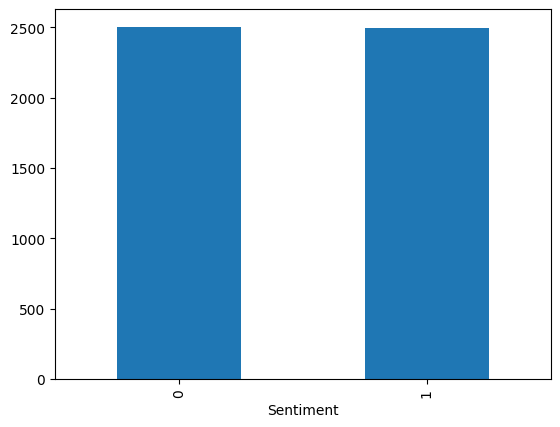

In [4]:
# visualize  sentiment
data.Sentiment.value_counts().plot(kind='bar')
plt.show()

In [5]:
# import spacy
import spacy

# load spacy mode
nlp = spacy.load('en_core_web_md')

In [6]:
# create movie comment sample and categories object
movie_comment_exp = []
categories = []

# perform tokenization and, add to movie_comment_exp and categories
for idx, rw in data.iterrows():
    comments = rw['Review']
    rating = rw['Sentiment']
    categories.append(rating)
    mtoks = [token.text for token in nlp(comments)]
    movie_comment_exp.append(mtoks)

In [ ]:
# review
movie_comment_exp[0]

In [8]:
# data and vocabulary preparation

# impot tokenizer and pad_sequences from tensorflow keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # pad_sequence digunakan agar kalimat memiliki panjang yang sama

import numpy as np

In [9]:
# crate object tokenizer 
ktoken = Tokenizer(lower=True)

# fit on text - movie_comment_exp
ktoken.fit_on_texts(movie_comment_exp)

# create movie_comment_exp to sequence object
seq_movie_comment_exp = ktoken.texts_to_sequences(movie_comment_exp)

In [10]:
# set the pad short to maximum length is 50
#set to MLEN 50
MLEN = 50

#create pad sequence
ps_movie_comment_exp = pad_sequences(seq_movie_comment_exp, MLEN, padding='post')

In [11]:
# convert movie commment into numpy array
ps_movie_comment_exp = np.array(ps_movie_comment_exp)

# create category list
catlist = np.array(categories)

In [12]:
# review catlist
catlist.shape

(5000,)

In [13]:
# reshape
catlist = catlist.reshape(catlist.shape[0], 1)

In [14]:
catlist.shape

(5000, 1)

data ready

In [43]:
# load model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras import Optimizer 

In [44]:
# implement the input layer
input_layer = Input(shape=(None,))

# shape none means that dimension can be any scalar number

In [45]:
# implement the embedding layer
embed_layer = Embedding(input_dim=len(ktoken.word_index)+1, output_dim=100)(input_layer)

'''
ketika embedding, layer yang diinput harus sebuah token dalam vocabulary. +1 karena indeks dimulai dari 1.
pada kode diatas, 100 dipilih menjadi output shape. token yang diinput akan diubah menjadi vektor 100 dimensi
'''

'\nketika embedding, layer yang diinput harus sebuah token dalam vocabulary. +1 karena indeks dimulai dari 1.\npada kode diatas, 100 dipilih menjadi output shape. token yang diinput akan diubah menjadi vektor 100 dimensi\n'

In [46]:
# implement the LSTM layer
LSTM_layerr = LSTM(units=256)(embed_layer)

# unit=256  adalah dimensi dari hiden state pada lstm

In [48]:
# implement the output layer
output_layer = Dense(1, activation='sigmoid')(LSTM_layerr)

'''
ketika sebuah 256 dimensional vektor dari LSTM didapatkan.
ini akan meringkas menjadi 1 dimensional vektor
nilai yang mungkin dari vektor ini adalah 0 dan 1

sigmoid function : s-shape fungsi aktivasi yang digunakan untuk memetakan nilai input
menjadi nilai output dengan range 0-1
'''

'\nketika sebuah 256 dimensional vektor dari LSTM didapatkan.\nini akan meringkas menjadi 1 dimensional vektor\nnilai yang mungkin dari vektor ini adalah 0 dan 1\n\nsigmoid function : s-shape fungsi aktivasi yang digunakan untuk memetakan nilai input\nmenjadi nilai output dengan range 0-1\n'

In [49]:
# system compilation

# create LSTM model with data
imdb_mdl = Model(inputs=[input_layer], outputs=[output_layer])

In [50]:
# see the model setup
imdb_mdl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 100)      │     4,669,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       365,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,034,825 (19.21 MB)

 Trainable params: 5,034,825 (19.21 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# invoke model compilation
imdb_mdl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

'''
adam : adaptive moment estimation, optimizer yang efisien dan efektif
menggunakan binray cross-entropy sebagai loss function
'''

'\nadam : adaptive moment estimation, optimizer yang efisien dan efektif\nmenggunakan binray cross-entropy sebagai loss function\n'

In [52]:
# model training dan evaluation

# model fitting by using 5 epochs

imdb_mdl.fit(
    x=ps_movie_comment_exp,
    y=catlist,
    batch_size=64,
    epochs=5,
    validation_split=0.3
)

Epoch 1/5


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_4']
Received: inputs=Tensor(shape=(None, 50))
  warnings.warn(msg)


55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.5596 - loss: 0.6775 - val_accuracy: 0.7187 - val_loss: 0.5932
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.8489 - loss: 0.3886 - val_accuracy: 0.7273 - val_loss: 0.5440
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9399 - loss: 0.1984 - val_accuracy: 0.7267 - val_loss: 0.8684
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.9889 - loss: 0.0447 - val_accuracy: 0.7207 - val_loss: 0.9109
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9913 - loss: 0.0532 - val_accuracy: 0.6940 - val_loss: 1.4814
